<a href="https://colab.research.google.com/github/alfredmarkthewise-oss/InsurShield-/blob/main/quantum_gqt_production_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔷 Quantum Amplituhedron GQT Engine — Production Scale## 10-Layer Self-Improving Quantum Geometric Intelligence**Architecture:** Amplituhedron → Transforms → Lee-Wick → GQT (K2 Gates) → LeWM (JEPA) → SIGReg → Hyperagent → Meta-Meta → TurboQuant → RL Loop**Requirements:** Google Colab Pro+ with A100 GPU### Cell 0: Setup & Installation

In [1]:
# ═══ CELL 0: SETUP & INSTALLATION ═══
!pip install -q torch einops wandb matplotlib plotly bitsandbytes

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import math, random, json, os, time
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Mount Google Drive for persistence
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/quantum_gqt/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
TAU = 2 * math.pi
PHI = (1 + math.sqrt(5)) / 2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.4 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Mounted at /content/drive
Save directory: /content/drive/MyDrive/quantum_gqt/


### Cell 1: Layer 1 — Amplituhedron ChamberGeometric foundation. Computes quantum scattering amplitudes from shape topology.

In [2]:
# ═══ LAYER 1: AMPLITUHEDRON CHAMBER ═══

# Shape definitions as GPU tensors
SHAPES = {}

def _make_shape(name, verts, edges):
    SHAPES[name] = {
        'verts': torch.tensor(verts, dtype=torch.float32, device=device),
        'edges': torch.tensor(edges, dtype=torch.long, device=device),
    }

_make_shape('tetrahedron',
    [[0.6,0.6,0.6],[-0.6,-0.6,0.6],[-0.6,0.6,-0.6],[0.6,-0.6,-0.6]],
    [[0,1],[0,2],[0,3],[1,2],[1,3],[2,3]])

_make_shape('cube',
    [[-0.55,-0.55,-0.55],[0.55,-0.55,-0.55],[0.55,0.55,-0.55],[-0.55,0.55,-0.55],
     [-0.55,-0.55,0.55],[0.55,-0.55,0.55],[0.55,0.55,0.55],[-0.55,0.55,0.55]],
    [[0,1],[1,2],[2,3],[3,0],[4,5],[5,6],[6,7],[7,4],[0,4],[1,5],[2,6],[3,7]])

_make_shape('octahedron',
    [[0.8,0,0],[-0.8,0,0],[0,0.8,0],[0,-0.8,0],[0,0,0.8],[0,0,-0.8]],
    [[0,2],[0,3],[0,4],[0,5],[1,2],[1,3],[1,4],[1,5],[2,4],[2,5],[3,4],[3,5]])

n = 1/math.sqrt(1+PHI**2); p = PHI*n
_make_shape('icosahedron',
    [[0,n*1.1,p*1.1],[0,n*1.1,-p*1.1],[0,-n*1.1,p*1.1],[0,-n*1.1,-p*1.1],
     [n*1.1,p*1.1,0],[n*1.1,-p*1.1,0],[-n*1.1,p*1.1,0],[-n*1.1,-p*1.1,0],
     [p*1.1,0,n*1.1],[-p*1.1,0,n*1.1],[p*1.1,0,-n*1.1],[-p*1.1,0,-n*1.1]],
    [[0,2],[0,4],[0,6],[0,8],[0,9],[2,5],[2,7],[2,8],[2,9],[1,3],[1,4],[1,6],
     [1,10],[1,11],[3,5],[3,7],[3,10],[3,11],[4,6],[4,8],[4,10],[5,7],[5,8],
     [5,10],[6,9],[6,11],[7,9],[7,11],[8,10],[9,11]])


def compute_amplitude(verts: torch.Tensor, energy: float) -> dict:
    """Compute quantum scattering amplitude from vertex geometry."""
    # Vectorized amplitude computation
    phases = energy * (verts[:, 0] + verts[:, 1] * 0.7 + verts[:, 2] * 0.4)
    re = torch.cos(phases).mean()
    im = torch.sin(phases).mean()
    mag = torch.sqrt(re**2 + im**2)
    phase = torch.atan2(im, re)
    return {'re': re, 'im': im, 'mag': mag, 'phase': phase}


def compose_transform(verts: torch.Tensor, tf: dict) -> torch.Tensor:
    """Apply geometric transforms: scale → rotate → translate."""
    v = verts * tf['scale']
    # Rotation matrices (vectorized)
    cx, sx = math.cos(tf['rx']), math.sin(tf['rx'])
    cy, sy = math.cos(tf['ry']), math.sin(tf['ry'])
    cz, sz = math.cos(tf['rz']), math.sin(tf['rz'])
    Rx = torch.tensor([[1,0,0],[0,cx,-sx],[0,sx,cx]], device=device, dtype=torch.float32)
    Ry = torch.tensor([[cy,0,sy],[0,1,0],[-sy,0,cy]], device=device, dtype=torch.float32)
    Rz = torch.tensor([[cz,-sz,0],[sz,cz,0],[0,0,1]], device=device, dtype=torch.float32)
    R = Rz @ Ry @ Rx
    v = (R @ v.T).T
    v = v + torch.tensor([tf['tx'], tf['ty'], tf['tz']], device=device)
    return v


def reflect_vertices(verts: torch.Tensor, axis: int) -> torch.Tensor:
    """Reflect vertices across a plane."""
    reflected = verts.clone()
    reflected[:, axis] = -reflected[:, axis]
    return reflected


def lee_wick_force(dx: torch.Tensor, amplitude: float, ghost_mass: float) -> torch.Tensor:
    """Lee-Wick regularized force: cancels UV divergence."""
    d2 = (dx**2).sum(dim=-1, keepdim=True) + 1e-4
    d = torch.sqrt(d2)
    regular = 1.0 / d2
    ghost = torch.exp(-ghost_mass * d) / d2
    regularized = (regular - ghost) * amplitude
    return dx * regularized


print(f"Shapes loaded: {list(SHAPES.keys())}")
print(f"Tetrahedron verts shape: {SHAPES['tetrahedron']['verts'].shape}")
print("Layer 1: Amplituhedron Chamber ✓")

Shapes loaded: ['tetrahedron', 'cube', 'octahedron', 'icosahedron']
Tetrahedron verts shape: torch.Size([4, 3])
Layer 1: Amplituhedron Chamber ✓


### Cell 2: Layers 2-3 — Geometric Transforms & Electron Dynamics4 simultaneous transforms (TR/DL/RT/RF) + particle dynamics with Lee-Wick ghosts.

In [3]:
# ═══ LAYERS 2-3: TRANSFORMS & ELECTRON DYNAMICS ═══

TAU = 2 * math.pi # Added to fix NameError

@dataclass
class ElectronState:
    pos: torch.Tensor         # [N, 3] positions
    vel: torch.Tensor         # [N, 3] velocities
    phase: torch.Tensor       # [N] quantum phases
    acc_phase: torch.Tensor   # [N] accumulated Berry phase
    hue: torch.Tensor         # [N] color hue for visualization

@dataclass
class GhostState:
    pos: torch.Tensor         # [N, 3]
    vel: torch.Tensor         # [N, 3]
    decay: torch.Tensor       # [N] decay factor (0-1)

@dataclass
class TransformConfig:
    tr_on: bool = True;  tr_auto: bool = True
    dl_on: bool = False; dl_auto: bool = True
    rt_on: bool = False; rt_auto: bool = True
    rf_on: bool = False; rf_axis: int = 0
    lw_on: bool = False; lw_mass: float = 3.0

@dataclass
class QuantumState:
    spin_angle: torch.Tensor    # [N]
    spin_up: torch.Tensor       # [N]
    parity: torch.Tensor        # [N] -1, 0, +1
    confinement_E: torch.Tensor # [N]
    localization: torch.Tensor  # [N]
    berry_phase: torch.Tensor   # [N]
    prob_density: torch.Tensor  # [N]


def init_electrons(n_electrons: int) -> Tuple[ElectronState, GhostState]:
    angles = torch.linspace(0, TAU, n_electrons + 1, device=device)[:n_electrons]
    pos = torch.stack([torch.cos(angles)*0.5, torch.sin(angles)*0.3,
                       torch.sin(angles*1.5)*0.4], dim=-1)
    electrons = ElectronState(
        pos=pos, vel=torch.zeros(n_electrons, 3, device=device),
        phase=torch.rand(n_electrons, device=device) * TAU,
        acc_phase=torch.zeros(n_electrons, device=device),
        hue=torch.linspace(0, 360, n_electrons + 1, device=device)[:n_electrons])
    ghosts = GhostState(
        pos=pos + 0.05, vel=torch.zeros(n_electrons, 3, device=device),
        decay=torch.ones(n_electrons, device=device))
    return electrons, ghosts


def compute_quantum_state(electrons: ElectronState, tf: dict, amplitude: dict,
                          rf_on: bool, rf_axis: int, energy: float) -> QuantumState:
    """Compute quantum observables for all electrons."""
    N = electrons.pos.shape[0]
    tR = math.sqrt(tf['rx']**2 + tf['ry']**2 + tf['rz']**2)
    spin_angle = electrons.phase + tR * 0.5
    spin_up = torch.cos(spin_angle / 2)**2

    # Parity
    parity = torch.zeros(N, device=device)
    if rf_on:
        coords = electrons.pos[:, rf_axis]
        parity = torch.where(coords.abs() < 0.05, torch.zeros_like(coords),
                             torch.sign(coords))

    loc = max(0.3, min(3.0, 1.0 / tf['scale']))
    cE = energy / (tf['scale']**2)
    prob_density = torch.clamp(amplitude['mag'] * (0.5 + 0.5 * math.exp(-loc * 0.3)), 0.1, 0.95)

    berry = (tf['tx'] * electrons.pos[:, 0] + tf['ty'] * electrons.pos[:, 1] +
             tf['tz'] * electrons.pos[:, 2] + tR * 0.5) % TAU

    return QuantumState(
        spin_angle=spin_angle, spin_up=spin_up, parity=parity,
        confinement_E=torch.full((N,), cE, device=device),
        localization=torch.full((N,), loc, device=device),
        berry_phase=berry,
        prob_density=torch.full((N,), prob_density.item() if isinstance(prob_density, torch.Tensor) else prob_density, device=device))


def step_dynamics(electrons: ElectronState, ghosts: GhostState, all_verts: torch.Tensor,
                  amplitude: dict, t: float, speed: float, lw_on: bool, lw_mass: float):
    """Advance electron and ghost dynamics one timestep."""
    N = electrons.pos.shape[0]
    nV = all_verts.shape[0]

    # Electron-vertex forces [N, nV, 3]
    diff = all_verts.unsqueeze(0) - electrons.pos.unsqueeze(1)  # [N, nV, 3]

    if lw_on:
        force = lee_wick_force(diff, 0.02 * amplitude['mag'].item(), lw_mass)
    else:
        d2 = (diff**2).sum(-1, keepdim=True) + 0.01
        force = diff * 0.005 / d2

    total_force = force.sum(dim=1)  # [N, 3]

    # Orbital motion
    orbital = torch.stack([
        torch.cos(t * 0.8 + electrons.phase + torch.arange(N, device=device).float()) * 0.015,
        torch.sin(t * 0.7 + electrons.phase) * 0.015,
        torch.cos(t * 0.5 + electrons.phase * 2) * 0.01], dim=-1)

    total_force = total_force + orbital

    # Update velocities and positions
    electrons.vel = electrons.vel * 0.92 + total_force * speed
    electrons.pos = torch.clamp(electrons.pos + electrons.vel * 0.016, -1.7, 1.7)

    # Ghost dynamics
    if lw_on:
        ghost_diff = electrons.pos - ghosts.pos
        coupling = 0.04 * ghosts.decay.unsqueeze(-1)
        ghosts.vel = ghosts.vel * 0.85 + ghost_diff * coupling * speed
        ghosts.pos = torch.clamp(ghosts.pos + ghosts.vel * 0.016, -1.7, 1.7)
        ghosts.decay = 0.5 + 0.5 * torch.sin(torch.tensor(t * 0.3, device=device) +
                       torch.arange(N, device=device).float() * 2)


print(f"Electron dynamics initialized on {device}")
# Test
els, ghs = init_electrons(4)
print(f"Electrons: {els.pos.shape}, Ghosts: {ghs.pos.shape}")
print("Layers 2-3: Transforms & Dynamics ✓")

Electron dynamics initialized on cuda
Electrons: torch.Size([4, 3]), Ghosts: torch.Size([4, 3])
Layers 2-3: Transforms & Dynamics ✓


### Cell 3: Layers 4-5 — Lee-Wick Regularization & GQT Transformer5-head attention (Pauli, Coulomb, Symmetry, SpinOrbit, LeeWick) with K2 context-driven gates.

In [4]:
# ═══ LAYERS 4-5: GQT TRANSFORMER WITH K2 GATES ═══

HEAD_NAMES = ["Pauli", "Coulomb", "Symmetry", "SpinOrbit", "LeeWick"]
HEAD_COLORS = ["#c084fc", "#fb923c", "#f472b6", "#38bdf8", "#ef4444"]

class ContextGate(nn.Module):
    """K2 gate: context-driven, not token-driven. Inherently stable."""
    def __init__(self, context_dim=7, init_bias=0.0):
        super().__init__()
        self.context_proj = nn.Linear(context_dim, 1)
        self.bias = nn.Parameter(torch.tensor(init_bias))
        self.ema_val = init_bias  # for smooth tracking

    def forward(self, context: torch.Tensor) -> torch.Tensor:
        raw = torch.sigmoid(self.context_proj(context).squeeze(-1) + self.bias)
        # EMA smoothing
        self.ema_val = self.ema_val * 0.95 + raw.mean().item() * 0.05
        return raw


class GQTransformer(nn.Module):
    """5-head Geometric Quantum Transformer with K2 gated residuals."""
    def __init__(self, token_dim=512, hidden_dim=250, n_heads=5, n_layers=4, context_dim=7):
        super().__init__()
        self.token_dim = token_dim
        self.hidden_dim = hidden_dim
        self.n_heads = n_heads
        self.n_layers = n_layers

        # Input projection
        self.input_proj = nn.Linear(token_dim, hidden_dim)

        # Multi-layer attention
        self.layers = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(nn.ModuleDict({
                'attention': nn.MultiheadAttention(hidden_dim, n_heads, batch_first=True, dropout=0.1),
                'norm1': nn.LayerNorm(hidden_dim),
                'ffn': nn.Sequential(nn.Linear(hidden_dim, hidden_dim*4), nn.GELU(), nn.Linear(hidden_dim*4, hidden_dim)),
                'norm2': nn.LayerNorm(hidden_dim),
            }))

        # K2 gates: one per physics head, context-driven
        init_biases = [-0.5, 0.3, -0.2, 0.6, -0.8]
        self.gates = nn.ModuleList([ContextGate(context_dim, b) for b in init_biases])

        # Head-specific output projections
        head_dim = hidden_dim // n_heads
        self.head_projs = nn.ModuleList([nn.Linear(head_dim, hidden_dim) for _ in range(n_heads)])

        # Output projection
        self.output_proj = nn.Linear(hidden_dim, token_dim)

        # Sequence buffer
        self.seq_buffer = deque(maxlen=64)
        self.gate_history = deque(maxlen=200)
        self.loss_history = deque(maxlen=500)
        self.step = 0

    def forward(self, x: torch.Tensor, context: torch.Tensor) -> Tuple[torch.Tensor, List[float]]:
        """Forward pass with gated multi-head attention."""
        h = self.input_proj(x)  # [B, seq_len, hidden_dim]

        # Multi-layer attention
        for layer in self.layers:
            # Self-attention
            attn_out, _ = layer['attention'](h, h, h)
            h = layer['norm1'](h + attn_out)
            # FFN
            h = layer['norm2'](h + layer['ffn'](h))

        # Split into heads and apply K2 gates
        head_dim = self.hidden_dim // self.n_heads
        heads = h.split(head_dim, dim=-1)  # 5 × [B, seq_len, head_dim]

        gate_values = []
        gated_output = torch.zeros_like(h)
        for i, (head, gate, proj) in enumerate(zip(heads, self.gates, self.head_projs)):
            g = gate(context)  # [B]
            gate_values.append(g.mean().item())
            gated_output = gated_output + proj(head) * g.unsqueeze(-1).unsqueeze(-1)

        output = self.output_proj(gated_output)
        return output, gate_values

    def train_step(self, prev_token, next_token, context, optimizer):
        """One training step: predict next token from previous."""
        self.train()
        optimizer.zero_grad()

        pred, gate_values = self.forward(prev_token.unsqueeze(0).unsqueeze(0), context.unsqueeze(0))
        pred = pred.squeeze(0).squeeze(0)

        loss = F.mse_loss(pred[:64], next_token[:64])  # predict first 64 dims
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.parameters(), 1.0)
        optimizer.step()

        self.step += 1
        self.loss_history.append(loss.item())
        self.gate_history.append(gate_values)

        return loss.item(), gate_values


# Initialize
TOKEN_DIM = 512   # production scale (was 108 in demo)
HIDDEN_DIM = 250  # production scale, changed from 256 to be divisible by 5 heads
N_LAYERS = 4      # production scale (was 1 in demo)

gqt = GQTransformer(TOKEN_DIM, HIDDEN_DIM, n_heads=5, n_layers=N_LAYERS).to(device)
gqt_optimizer = optim.AdamW(gqt.parameters(), lr=2e-4, weight_decay=0.01)

n_params = sum(p.numel() for p in gqt.parameters())
print(f"GQT parameters: {n_params:,} ({n_params/1e6:.1f}M)")
print(f"Token dim: {TOKEN_DIM}, Hidden dim: {HIDDEN_DIM}, Layers: {N_LAYERS}")
print(f"Attention heads: {gqt.n_heads} ({', '.join(HEAD_NAMES)})")
print("Layers 4-5: GQT + K2 Gates ✓")

GQT parameters: 3,333,557 (3.3M)
Token dim: 512, Hidden dim: 250, Layers: 4
Attention heads: 5 (Pauli, Coulomb, Symmetry, SpinOrbit, LeeWick)
Layers 4-5: GQT + K2 Gates ✓


### Cell 4: Layer 6 — LeWM Latent World Model (JEPA)Encoder compresses state → latent z. Predictor: z_t + action → z_{t+1}. SIGReg prevents collapse.

In [5]:
# ═══ LAYER 6: LeWM (JEPA LATENT WORLD MODEL) ═══

class SIGReg(nn.Module):
    """SIGReg regularization: enforce Gaussian latent distribution.
    Projects latent embeddings onto random directions, tests normality."""
    def __init__(self, latent_dim: int, n_projections: int = 16):
        super().__init__()
        # Random projection directions (fixed, not learned)
        proj = torch.randn(n_projections, latent_dim)
        proj = proj / proj.norm(dim=-1, keepdim=True)
        self.register_buffer('projections', proj)

    def forward(self, latents: torch.Tensor) -> torch.Tensor:
        """Compute SIGReg loss on a batch of latent vectors."""
        if latents.shape[0] < 4:
            return torch.tensor(0.0, device=latents.device)
        # Project onto random directions: [n_proj, batch]
        projected = torch.mm(self.projections, latents.T)
        # For each projection, penalize deviation from N(0,1)
        means = projected.mean(dim=1)
        stds = projected.std(dim=1) + 1e-6
        # Normality penalty: mean should be 0, std should be 1
        loss = (means**2).mean() + ((stds - 1)**2).mean()
        return loss


class LeWorldModel(nn.Module):
    """LeWM: JEPA-based latent world model.
    Encoder: token → latent z
    Predictor: z_t + action → z_{t+1}
    Trained with prediction loss + SIGReg regularization."""
    def __init__(self, input_dim=512, latent_dim=64, action_dim=12):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 3-layer MLP with layer norm
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.GELU(),
            nn.Linear(128, latent_dim), nn.Tanh())

        # Predictor: z + action → next_z (3-layer MLP)
        self.predictor = nn.Sequential(
            nn.Linear(latent_dim + action_dim, 128), nn.LayerNorm(128), nn.GELU(),
            nn.Linear(128, 128), nn.LayerNorm(128), nn.GELU(),
            nn.Linear(128, latent_dim), nn.Tanh())

        # SIGReg
        self.sigreg = SIGReg(latent_dim, n_projections=16)

        # History
        self.loss_history = deque(maxlen=500)
        self.surprise_history = deque(maxlen=500)
        self.sigreg_history = deque(maxlen=500)
        self.latent_buffer = deque(maxlen=64)
        self.step = 0
        self.collapse = False

    def encode(self, token: torch.Tensor) -> torch.Tensor:
        return self.encoder(token)

    def predict(self, z: torch.Tensor, action: torch.Tensor) -> torch.Tensor:
        return self.predictor(torch.cat([z, action], dim=-1))

    def compute_surprise(self, z_pred: torch.Tensor, z_actual: torch.Tensor) -> float:
        return F.mse_loss(z_pred, z_actual).sqrt().item()

    def train_step(self, prev_token, cur_token, action, optimizer, sigreg_weight=0.1):
        self.train()
        optimizer.zero_grad()

        z_prev = self.encode(prev_token)
        z_cur = self.encode(cur_token)
        z_pred = self.predict(z_prev, action)

        # Prediction loss
        pred_loss = F.mse_loss(z_pred, z_cur.detach())

        # SIGReg
        self.latent_buffer.append(z_cur.detach())
        if len(self.latent_buffer) >= 8:
            latent_batch = torch.stack(list(self.latent_buffer))
            sigreg_loss = self.sigreg(latent_batch)
        else:
            sigreg_loss = torch.tensor(0.0, device=prev_token.device)

        total_loss = pred_loss + sigreg_weight * sigreg_loss
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.parameters(), 1.0)
        optimizer.step()

        surprise = self.compute_surprise(z_pred.detach(), z_cur.detach())

        self.step += 1
        self.loss_history.append(total_loss.item())
        self.surprise_history.append(surprise)
        self.sigreg_history.append(sigreg_loss.item())
        self.collapse = sigreg_loss.item() > 0.5

        return {'pred_loss': pred_loss.item(), 'sigreg_loss': sigreg_loss.item(),
                'total_loss': total_loss.item(), 'surprise': surprise}


# Initialize
LATENT_DIM = 64  # production scale (was 16 in demo)
ACTION_DIM = 12

lewm = LeWorldModel(TOKEN_DIM, LATENT_DIM, ACTION_DIM).to(device)
lewm_optimizer = optim.AdamW(lewm.parameters(), lr=3e-4, weight_decay=0.01)

n_params_lewm = sum(p.numel() for p in lewm.parameters())
print(f"LeWM parameters: {n_params_lewm:,} ({n_params_lewm/1e6:.1f}M)")
print(f"Latent dim: {LATENT_DIM}, SIGReg projections: 16")
print("Layer 6: LeWM (JEPA) + SIGReg ✓")

LeWM parameters: 208,384 (0.2M)
Latent dim: 64, SIGReg projections: 16
Layer 6: LeWM (JEPA) + SIGReg ✓


### Cell 5: Layers 7-8 — Hyperagent (Self-Modifying Meta-Agent)Meta agent modifies GQT/LeWM hyperparameters. Meta-meta layer modifies the modification strategy.

In [6]:
# ═══ LAYERS 7-8: HYPERAGENT ═══

class Hyperagent:
    """Self-modifying meta-agent with meta-meta learning."""
    def __init__(self):
        self.step = 0
        self.log = deque(maxlen=100)
        self.perf_history = deque(maxlen=500)
        self.meta_strat_history = deque(maxlen=200)

        # Modifiable strategy weights
        self.strategy = {'gqt_lr': 0.5, 'lewm_lr': 0.5, 'sigreg_w': 0.3,
                         'gate_bias': 0.2, 'lw_mass': 0.1}
        # Meta-meta parameters
        self.meta_lr = 0.1
        self.strategy_age = 0
        self.improvements = 0
        self.regressions = 0
        self.improvement_rate = 0.5
        self.prev_loss = float('inf')
        self.prev_surprise = float('inf')
        self.discovered_rules = deque(maxlen=30)

    def evaluate(self, gqt, lewm, unitarity):
        gqt_loss = gqt.loss_history[-1] if gqt.loss_history else 1.0
        lewm_loss = lewm.loss_history[-1] if lewm.loss_history else 1.0
        surprise = lewm.surprise_history[-1] if lewm.surprise_history else 1.0
        collapse = lewm.collapse
        score = 1.0 / (1.0 + gqt_loss + lewm_loss)
        if collapse: score *= 0.5
        score *= max(0, 1 - abs(unitarity - 1) * 2)
        return {'gqt_loss': gqt_loss, 'lewm_loss': lewm_loss, 'surprise': surprise,
                'collapse': collapse, 'score': score, 'unitarity': unitarity}

    def modify(self, gqt_optimizer, lewm_optimizer, perf):
        mods = []
        # GQT learning rate
        if perf['gqt_loss'] > self.prev_loss * 1.1:
            delta = -self.strategy['gqt_lr'] * 0.0001
            for pg in gqt_optimizer.param_groups:
                pg['lr'] = max(1e-5, min(0.01, pg['lr'] + delta))
            mods.append(f"GQT.lr → {gqt_optimizer.param_groups[0]['lr']:.6f} (loss↑)")
        elif perf['gqt_loss'] < self.prev_loss * 0.9:
            delta = self.strategy['gqt_lr'] * 0.00005
            for pg in gqt_optimizer.param_groups:
                pg['lr'] = max(1e-5, min(0.01, pg['lr'] + delta))
            mods.append(f"GQT.lr → {gqt_optimizer.param_groups[0]['lr']:.6f} (loss↓)")
        # LeWM on collapse
        if perf['collapse']:
            for pg in lewm_optimizer.param_groups:
                pg['lr'] *= 0.95
            mods.append(f"LeWM.lr → {lewm_optimizer.param_groups[0]['lr']:.6f} (collapse!)")
        return mods

    def meta_modify(self, perf):
        improved = perf['score'] > (self.perf_history[-2] if len(self.perf_history) >= 2 else 0)
        if improved: self.improvements += 1
        else: self.regressions += 1
        self.improvement_rate = self.improvements / max(1, self.improvements + self.regressions)
        # Mutate strategy if not working
        if self.improvement_rate < 0.4 and self.step > 20:
            key = random.choice(list(self.strategy.keys()))
            old = self.strategy[key]
            self.strategy[key] = max(0.01, min(2.0, old + (random.random() - 0.5) * self.meta_lr))
            self.discovered_rules.append(
                f"Step {self.step}: Mutated {key} {old:.3f}→{self.strategy[key]:.3f} (rate={self.improvement_rate:.2f})")
            self.strategy_age = 0
        if self.improvement_rate > 0.6 and self.strategy_age > 10:
            for k in self.strategy:
                self.strategy[k] = min(2.0, self.strategy[k] * 1.05)
            self.discovered_rules.append(f"Step {self.step}: Amplified all (rate={self.improvement_rate:.2f})")
        self.strategy_age += 1

    def tick(self, gqt, lewm, gqt_opt, lewm_opt, unitarity):
        perf = self.evaluate(gqt, lewm, unitarity)
        self.perf_history.append(perf['score'])
        mods = []
        if self.step % 10 == 0 and self.step > 10:
            mods = self.modify(gqt_opt, lewm_opt, perf)
            self.meta_modify(perf)
            self.meta_strat_history.append(dict(self.strategy))
        for m in mods:
            self.log.append(f"[{self.step}] {m}")
        self.prev_loss = perf['gqt_loss']
        self.prev_surprise = perf['surprise']
        self.step += 1
        return perf, mods


hyperagent = Hyperagent()
print(f"Hyperagent initialized with {len(hyperagent.strategy)} strategy params")
print(f"Discovered rules buffer: {hyperagent.discovered_rules.maxlen}")
print("Layers 7-8: Hyperagent + Meta-Meta ✓")

Hyperagent initialized with 5 strategy params
Discovered rules buffer: 30
Layers 7-8: Hyperagent + Meta-Meta ✓


### Cell 6: Layer 9 — TurboQuant CompressionPolarQuant + QJL with gate-aware adaptive bitwidth per attention head.

In [7]:
# ═══ LAYER 9: TURBOQUANT ═══

class TurboQuant:
    """Gate-aware adaptive quantization with PolarQuant + QJL."""
    def __init__(self, n_heads=5):
        self.head_bits = [4.0] * n_heads
        self.lewm_bits = 4.0
        self.head_errors = [0.0] * n_heads
        self.lewm_error = 0.0
        self.error_history = deque(maxlen=500)
        self.bits_history = deque(maxlen=200)
        self.savings_history = deque(maxlen=500)
        self.step = 0

    def polar_quantize_error(self, weight_tensor: torch.Tensor, bits: int) -> float:
        """Measure quantization error using PolarQuant + QJL (non-destructive)."""
        with torch.no_grad():
            w = weight_tensor.flatten()[:1000]  # sample
            if w.numel() < 2: return 0.0
            # PolarQuant: convert pairs to polar
            pairs = w[:w.numel()//2*2].reshape(-1, 2)
            r = torch.sqrt((pairs**2).sum(-1))
            theta = torch.atan2(pairs[:, 1], pairs[:, 0])
            # Quantize
            levels = 2**bits
            r_q = torch.round(r * levels / (r.max() + 1e-8)) * (r.max() + 1e-8) / levels
            theta_q = torch.round((theta + math.pi) * levels / TAU) * TAU / levels - math.pi
            # Reconstruct
            recon = torch.stack([r_q * torch.cos(theta_q), r_q * torch.sin(theta_q)], -1)
            # QJL 1-bit correction
            residual = pairs - recon
            sign = torch.sign(residual)
            step_size = (r.max() + 1e-8) / levels
            corrected = recon + sign * step_size * 0.25
            error = (pairs - corrected).pow(2).mean().sqrt().item()
            return error

    def adapt_bits(self, gate_values: list):
        for h in range(len(self.head_bits)):
            g = gate_values[h] if h < len(gate_values) else 0.5
            target = 2.0 + g * 3.0  # gate=0→2bits, gate=1→5bits
            self.head_bits[h] += (target - self.head_bits[h]) * 0.15
            self.head_bits[h] = round(max(2, min(5, self.head_bits[h])) * 10) / 10

    def tick(self, gqt: GQTransformer, lewm: LeWorldModel):
        # Adapt bits from gate values
        if gqt.gate_history:
            self.adapt_bits(gqt.gate_history[-1])
        # Measure errors per head
        for h in range(min(5, len(gqt.layers[0]['attention'].in_proj_weight))):
            bits = round(self.head_bits[h])
            # Sample from attention weights
            w = gqt.layers[0]['attention'].in_proj_weight
            chunk = w.shape[0] // 3  # Q, K, V
            self.head_errors[h] = self.polar_quantize_error(w[:chunk], bits)
        # LeWM encoder error
        self.lewm_error = self.polar_quantize_error(lewm.encoder[0].weight, round(self.lewm_bits))
        # Calculate savings
        total_params = sum(p.numel() for p in gqt.parameters()) + sum(p.numel() for p in lewm.parameters())
        avg_bits = sum(self.head_bits) / len(self.head_bits)
        savings = 1.0 - avg_bits / 32.0
        avg_err = sum(self.head_errors) / max(1, len(self.head_errors))
        self.error_history.append(avg_err)
        self.bits_history.append(list(self.head_bits))
        self.savings_history.append(savings)
        self.step += 1
        return {'avg_err': avg_err, 'savings': savings, 'head_bits': list(self.head_bits)}


turboquant = TurboQuant(n_heads=5)
print(f"TurboQuant initialized: {turboquant.head_bits} bits/head")
print("Layer 9: TurboQuant ✓")

TurboQuant initialized: [4.0, 4.0, 4.0, 4.0, 4.0] bits/head
Layer 9: TurboQuant ✓


### Cell 7: Layer 10 — Reinforcement LoopCEM planner with composite reward, surprise-driven action trigger, latent space planning.

In [8]:
# ═══ LAYER 10: REINFORCEMENT LOOP ═══

SHAPE_NAMES = list(SHAPES.keys())

RL_ACTIONS = [
    ('toggle TR', lambda s: {**s, 'tr_on': not s['tr_on']}),
    ('toggle DL', lambda s: {**s, 'dl_on': not s['dl_on']}),
    ('toggle RT', lambda s: {**s, 'rt_on': not s['rt_on']}),
    ('toggle RF', lambda s: {**s, 'rf_on': not s['rf_on']}),
    ('toggle LW', lambda s: {**s, 'lw_on': not s['lw_on']}),
    ('E +0.5',    lambda s: {**s, 'energy': min(12, s['energy'] + 0.5)}),
    ('E -0.5',    lambda s: {**s, 'energy': max(0.5, s['energy'] - 0.5)}),
    ('mass +0.3', lambda s: {**s, 'lw_mass': min(8, s['lw_mass'] + 0.3)}),
    ('mass -0.3', lambda s: {**s, 'lw_mass': max(0.5, s['lw_mass'] - 0.3)}),
    ('next shape',lambda s: {**s, 'shape': SHAPE_NAMES[(SHAPE_NAMES.index(s['shape'])+1) % len(SHAPE_NAMES)]}),
    ('nEl +1',    lambda s: {**s, 'n_el': min(8, s['n_el'] + 1)}),
    ('do nothing', lambda s: s),
]


class RLAgent:
    def __init__(self, lewm: LeWorldModel, n_actions=12, plan_horizon=6,
                 cem_samples=64, cem_elite_frac=0.3, cem_iters=3):
        self.lewm = lewm
        self.n_actions = n_actions
        self.plan_horizon = plan_horizon
        self.cem_samples = cem_samples
        self.cem_elite = int(cem_samples * cem_elite_frac)
        self.cem_iters = cem_iters
        self.surprise_thresh = 0.08
        self.cooldown = 0
        self.step = 0
        self.reward_weights = {'unitarity': 0.3, 'compound': 0.2, 'surprise': 0.25,
                               'gate_div': 0.15, 'loss_red': 0.1}
        self.reward_history = deque(maxlen=500)
        self.action_log = deque(maxlen=50)
        self.prev_loss = 1.0

    def compute_reward(self, unitarity, compound_avg, surprise, gate_vals, gqt_loss):
        w = self.reward_weights
        r_u = 1 - abs(unitarity - 1) * 3
        r_c = compound_avg
        r_s = 1 - min(1, surprise * 3)
        mean_g = sum(gate_vals) / max(1, len(gate_vals))
        r_g = sum((g - mean_g)**2 for g in gate_vals) / max(1, len(gate_vals)) * 10
        r_l = max(-1, min(1, (self.prev_loss - gqt_loss) / max(0.001, self.prev_loss)))
        total = w['unitarity']*r_u + w['compound']*r_c + w['surprise']*r_s + w['gate_div']*r_g + w['loss_red']*r_l
        self.prev_loss = gqt_loss
        return max(-1, min(1, total))

    @torch.no_grad()
    def plan(self, cur_token, cur_state):
        """CEM planner in LeWM latent space."""
        cur_z = self.lewm.encode(cur_token)
        # Generate random action sequences [cem_samples, horizon]
        candidates = torch.randint(0, self.n_actions, (self.cem_samples, self.plan_horizon))

        for iteration in range(self.cem_iters):
            scores = []
            for seq in candidates:
                z = cur_z.clone()
                sim_state = dict(cur_state)
                total_r = 0
                for s, act_idx in enumerate(seq):
                    act_name, act_fn = RL_ACTIONS[act_idx.item()]
                    sim_state = act_fn(sim_state)
                    action_vec = torch.tensor([
                        float(sim_state.get('tr_on', False)), float(sim_state.get('dl_on', False)),
                        float(sim_state.get('rt_on', False)), float(sim_state.get('rf_on', False)),
                        float(sim_state.get('lw_on', False)), sim_state.get('energy', 3)/10,
                        sim_state.get('n_el', 4)/8, 0, 0, 0, 0, 0], device=device)
                    z = self.lewm.predict(z.unsqueeze(0), action_vec.unsqueeze(0)).squeeze(0)
                    z_var = z.pow(2).mean().item()
                    n_active = sum(1 for k in ['tr_on','dl_on','rt_on','rf_on','lw_on'] if sim_state.get(k))
                    is_toggle = act_idx.item() < 5
                    is_shape = act_idx.item() == 9
                    score = (0.5 * math.tanh(1 - z_var) + n_active * 0.08 +
                             (0.06 if is_toggle else (-0.02 if is_shape else 0.02)))
                    total_r += score * (0.9 ** s)
                scores.append(total_r)

            scores = torch.tensor(scores)
            elite_idx = scores.argsort(descending=True)[:self.cem_elite]
            elite = candidates[elite_idx]

            # Resample with mutation
            new_candidates = []
            for i in range(self.cem_samples):
                parent = elite[i % len(elite)].clone()
                n_mut = random.randint(1, 2)
                for _ in range(n_mut):
                    pos = random.randint(0, self.plan_horizon - 1)
                    parent[pos] = random.randint(0, self.n_actions - 1)
                new_candidates.append(parent)
            candidates = torch.stack(new_candidates)

        # Return best first action
        best_idx = scores.argsort(descending=True)[0]
        return candidates[best_idx][0].item(), scores[best_idx].item()

    def tick(self, cur_token, state, unitarity, compound_avg, surprise, gate_vals, gqt_loss):
        self.cooldown = max(0, self.cooldown - 1)
        self.step += 1
        reward = self.compute_reward(unitarity, compound_avg, surprise, gate_vals, gqt_loss)
        self.reward_history.append(reward)
        action = None
        if self.cooldown <= 0 and (surprise > self.surprise_thresh or self.step % 30 == 0 or self.step < 5):
            act_idx, planned_reward = self.plan(cur_token, state)
            act_name = RL_ACTIONS[act_idx][0]
            action = {'idx': act_idx, 'name': act_name, 'reward': planned_reward,
                      'surprise': surprise, 'step': self.step}
            self.action_log.append(action)
            self.cooldown = 10
        return reward, action


rl_agent = RLAgent(lewm, n_actions=len(RL_ACTIONS), cem_samples=64)
print(f"RL Agent: {len(RL_ACTIONS)} actions, {rl_agent.cem_samples} CEM samples")
print(f"Plan horizon: {rl_agent.plan_horizon}, Elite: {rl_agent.cem_elite}")
print("Layer 10: RL Loop ✓")

RL Agent: 12 actions, 64 CEM samples
Plan horizon: 6, Elite: 19
Layer 10: RL Loop ✓


### Cell 8: Tokenizer & Main Training LoopGenerates quantum state tokens, trains all layers, runs RL decisions. This is the main simulation.

In [9]:
# ═══ TOKENIZER & TRAINING LOOP ═══

def tokenize(electrons, quantum_states, ghosts, tf, amplitude, rf_on, rf_axis, lw_on):
    """Encode full system state into a token vector."""
    N = electrons.pos.shape[0]
    feats = []
    for i in range(N):
        feats.extend([
            electrons.pos[i, 0].item(), electrons.pos[i, 1].item(), electrons.pos[i, 2].item(),
            quantum_states.spin_angle[i].item(), quantum_states.parity[i].item(),
            quantum_states.prob_density[i].item(), quantum_states.berry_phase[i].item(),
            quantum_states.confinement_E[i].item(),
            ghosts.pos[i, 0].item(), ghosts.pos[i, 1].item(), ghosts.pos[i, 2].item(),
            ghosts.decay[i].item()])
    # Pad to fixed size
    while len(feats) < TOKEN_DIM - 12:
        feats.append(0.0)
    feats = feats[:TOKEN_DIM - 12]
    # Global features
    feats.extend([tf['tx'], tf['ty'], tf['tz'], tf['scale'], tf['rx'], tf['ry'], tf['rz'],
                  amplitude['mag'].item(), amplitude['phase'].item(),
                  float(rf_on), rf_axis / 2.0, float(lw_on)])
    return torch.tensor(feats[:TOKEN_DIM], dtype=torch.float32, device=device)


# ═══ MAIN TRAINING LOOP ═══
def run_simulation(n_steps=2000, n_electrons=4, energy=3.0, print_every=100):
    """Run the full 10-layer system."""
    # Initialize
    electrons, ghosts = init_electrons(n_electrons)
    shape_name = 'tetrahedron'
    t = 0.0
    speed = 1.0

    # RL state
    state = {'tr_on': True, 'dl_on': False, 'rt_on': False, 'rf_on': False,
             'lw_on': False, 'energy': energy, 'lw_mass': 3.0, 'shape': shape_name,
             'n_el': n_electrons}

    prev_token = None
    metrics = {'gqt_loss': [], 'lewm_loss': [], 'surprise': [], 'reward': [],
               'gates': [], 'unitarity': [], 'tq_savings': [], 'rl_actions': []}

    print(f"\n{'='*60}")
    print(f"  QUANTUM GQT ENGINE — {n_steps} step simulation")
    print(f"  {n_electrons} electrons | {shape_name} | E={energy}eV")
    print(f"  GQT: {sum(p.numel() for p in gqt.parameters()):,} params")
    print(f"  LeWM: {sum(p.numel() for p in lewm.parameters()):,} params")
    print(f"{'='*60}\n")

    for step in range(n_steps):
        t += 0.016 * speed

        # Layer 2: Compute transforms
        tf = {'tx': 0, 'ty': 0, 'tz': 0, 'scale': 1.0, 'rx': 0, 'ry': 0, 'rz': 0}
        if state['tr_on']:
            tf['tx'] = math.sin(t*0.8)*0.7; tf['ty'] = math.cos(t*0.6)*0.35; tf['tz'] = math.sin(t*0.5)*0.4
        if state['dl_on']:
            tf['scale'] = 0.5 + math.sin(t*0.7)*0.5 + 0.5
        if state['rt_on']:
            tf['rx'] = t*0.8; tf['ry'] = t*1.2; tf['rz'] = t*0.4
        if state['rf_on']:
            tf['tx'] += 0.15 if state['tr_on'] else 0.35

        # Layer 1: Amplituhedron
        shape = SHAPES[state['shape']]
        tx_verts = compose_transform(shape['verts'], tf)
        amplitude = compute_amplitude(tx_verts, state['energy'])

        # Reflection
        all_verts = tx_verts
        rf_axis = 0
        if state['rf_on']:
            all_verts = torch.cat([tx_verts, reflect_vertices(tx_verts, rf_axis)])

        # Layer 3: Dynamics
        step_dynamics(electrons, ghosts, all_verts, amplitude, t, speed,
                      state['lw_on'], state['lw_mass'])

        # Quantum state
        qs = compute_quantum_state(electrons, tf, amplitude, state['rf_on'], rf_axis, state['energy'])

        # Lee-Wick regularized probabilities
        sim_p = qs.prob_density.clone()
        if state['lw_on']:
            g_dist = (electrons.pos - ghosts.pos).pow(2).sum(-1).sqrt()
            ghost_contrib = sim_p * ghosts.decay * torch.exp(-g_dist * state['lw_mass'] * 0.5)
            sim_p = torch.clamp(sim_p - ghost_contrib, 0.01, 0.99)
        unitarity = sim_p.mean().item()

        # Tokenize
        token = tokenize(electrons, qs, ghosts, tf, amplitude,
                         state['rf_on'], rf_axis, state['lw_on'])

        # Context vector for gates
        context = torch.tensor([float(state['tr_on']), float(state['dl_on']),
                                float(state['rt_on']), float(state['rf_on']),
                                float(state['lw_on']), state['energy']/10,
                                state['n_el']/8], device=device)

        # Train GQT + LeWM
        if prev_token is not None and step % 3 == 0:
            # Layer 5: GQT training
            gqt_loss, gate_vals = gqt.train_step(prev_token, token, context, gqt_optimizer)
            metrics['gqt_loss'].append(gqt_loss)
            metrics['gates'].append(gate_vals)

            # Layer 6: LeWM training
            action_vec = torch.tensor([tf['tx'], tf['ty'], tf['tz'], tf['scale'],
                                       tf['rx'], tf['ry'], tf['rz'], amplitude['mag'].item(),
                                       float(state['rf_on']), rf_axis/2, float(state['lw_on']),
                                       state['energy']/10], device=device)
            lewm_result = lewm.train_step(prev_token, token, action_vec, lewm_optimizer)
            metrics['lewm_loss'].append(lewm_result['total_loss'])
            metrics['surprise'].append(lewm_result['surprise'])

            # Layer 7-8: Hyperagent
            perf, mods = hyperagent.tick(gqt, lewm, gqt_optimizer, lewm_optimizer, unitarity)

            # Layer 9: TurboQuant
            tq_result = turboquant.tick(gqt, lewm)
            metrics['tq_savings'].append(tq_result['savings'])

            # Layer 10: RL
            compound_avg = sim_p.mean().item()
            surprise = lewm_result['surprise']
            reward, action = rl_agent.tick(
                token, state, unitarity, compound_avg, surprise,
                gate_vals, gqt_loss)
            metrics['reward'].append(reward)
            metrics['unitarity'].append(unitarity)

            if action:
                act_fn = RL_ACTIONS[action['idx']][1]
                state = act_fn(state)
                metrics['rl_actions'].append(action)

        prev_token = token.detach()

        # Print progress
        if (step + 1) % print_every == 0:
            gl = f"{metrics['gqt_loss'][-1]:.5f}" if metrics['gqt_loss'] else "—"
            ll = f"{metrics['lewm_loss'][-1]:.5f}" if metrics['lewm_loss'] else "—"
            sr = f"{metrics['surprise'][-1]:.4f}" if metrics['surprise'] else "—"
            rw = f"{metrics['reward'][-1]:.3f}" if metrics['reward'] else "—"
            gv = [f"{g:.0%}" for g in metrics['gates'][-1]] if metrics['gates'] else ["—"]*5
            sv = f"{metrics['tq_savings'][-1]:.1%}" if metrics['tq_savings'] else "—"
            ut = f"{metrics['unitarity'][-1]:.3f}" if metrics['unitarity'] else "—"
            acts = [a['name'] for a in metrics['rl_actions'][-3:]]
            cfg = '+'.join(k[:2].upper() for k,v in state.items() if k.endswith('_on') and v)

            print(f"Step {step+1:5d} | GQT:{gl} LeWM:{ll} | Surp:{sr} Rwd:{rw}")
            print(f"         | Gates: {' '.join(gv)} | TQ:{sv} Σψ²:{ut}")
            print(f"         | Config: {cfg or 'IDENTITY'} | Shape: {state['shape']} E={state['energy']:.1f}")
            if acts:
                print(f"         | RL actions: {', '.join(acts)}")
            if hyperagent.log:
                print(f"         | Hyper: {list(hyperagent.log)[-1]}")
            print()

    return metrics, state


# RUN THE SIMULATION
print("Starting 10-layer quantum simulation...\n")
metrics, final_state = run_simulation(n_steps=2000, n_electrons=4, energy=3.0, print_every=200)
print(f"\nSimulation complete. Final config: {final_state}")

Starting 10-layer quantum simulation...


  QUANTUM GQT ENGINE — 2000 step simulation
  4 electrons | tetrahedron | E=3.0eV
  GQT: 3,333,557 params
  LeWM: 208,384 params

Step   200 | GQT:0.02604 LeWM:0.10082 | Surp:0.0831 Rwd:-0.118
         | Gates: 53% 56% 60% 72% 36% | TQ:88.4% Σψ²:0.228
         | Config: TR+DL+RT+LW | Shape: tetrahedron E=2.5
         | RL actions: toggle LW, E -0.5, toggle RF
         | Hyper: [60] LeWM.lr → 0.000232 (collapse!)

Step   400 | GQT:0.76193 LeWM:0.11360 | Surp:0.0280 Rwd:-0.117
         | Gates: 62% 50% 68% 79% 43% | TQ:88.4% Σψ²:0.210
         | Config: TR+DL+RT+RF+LW | Shape: tetrahedron E=3.0
         | RL actions: E +0.5, toggle RF, do nothing
         | Hyper: [130] LeWM.lr → 0.000162 (collapse!)

Step   600 | GQT:5.02777 LeWM:0.11334 | Surp:0.0514 Rwd:0.165
         | Gates: 63% 50% 69% 80% 44% | TQ:88.4% Σψ²:0.480
         | Config: TR+DL+RT+RF+LW | Shape: tetrahedron E=3.0
         | RL actions: do nothing, mass +0.3, nEl +1
         | Hyp

### Cell 9: Visualization DashboardRecreates the browser dashboard in matplotlib — gates, loss, surprise, rewards, compression.

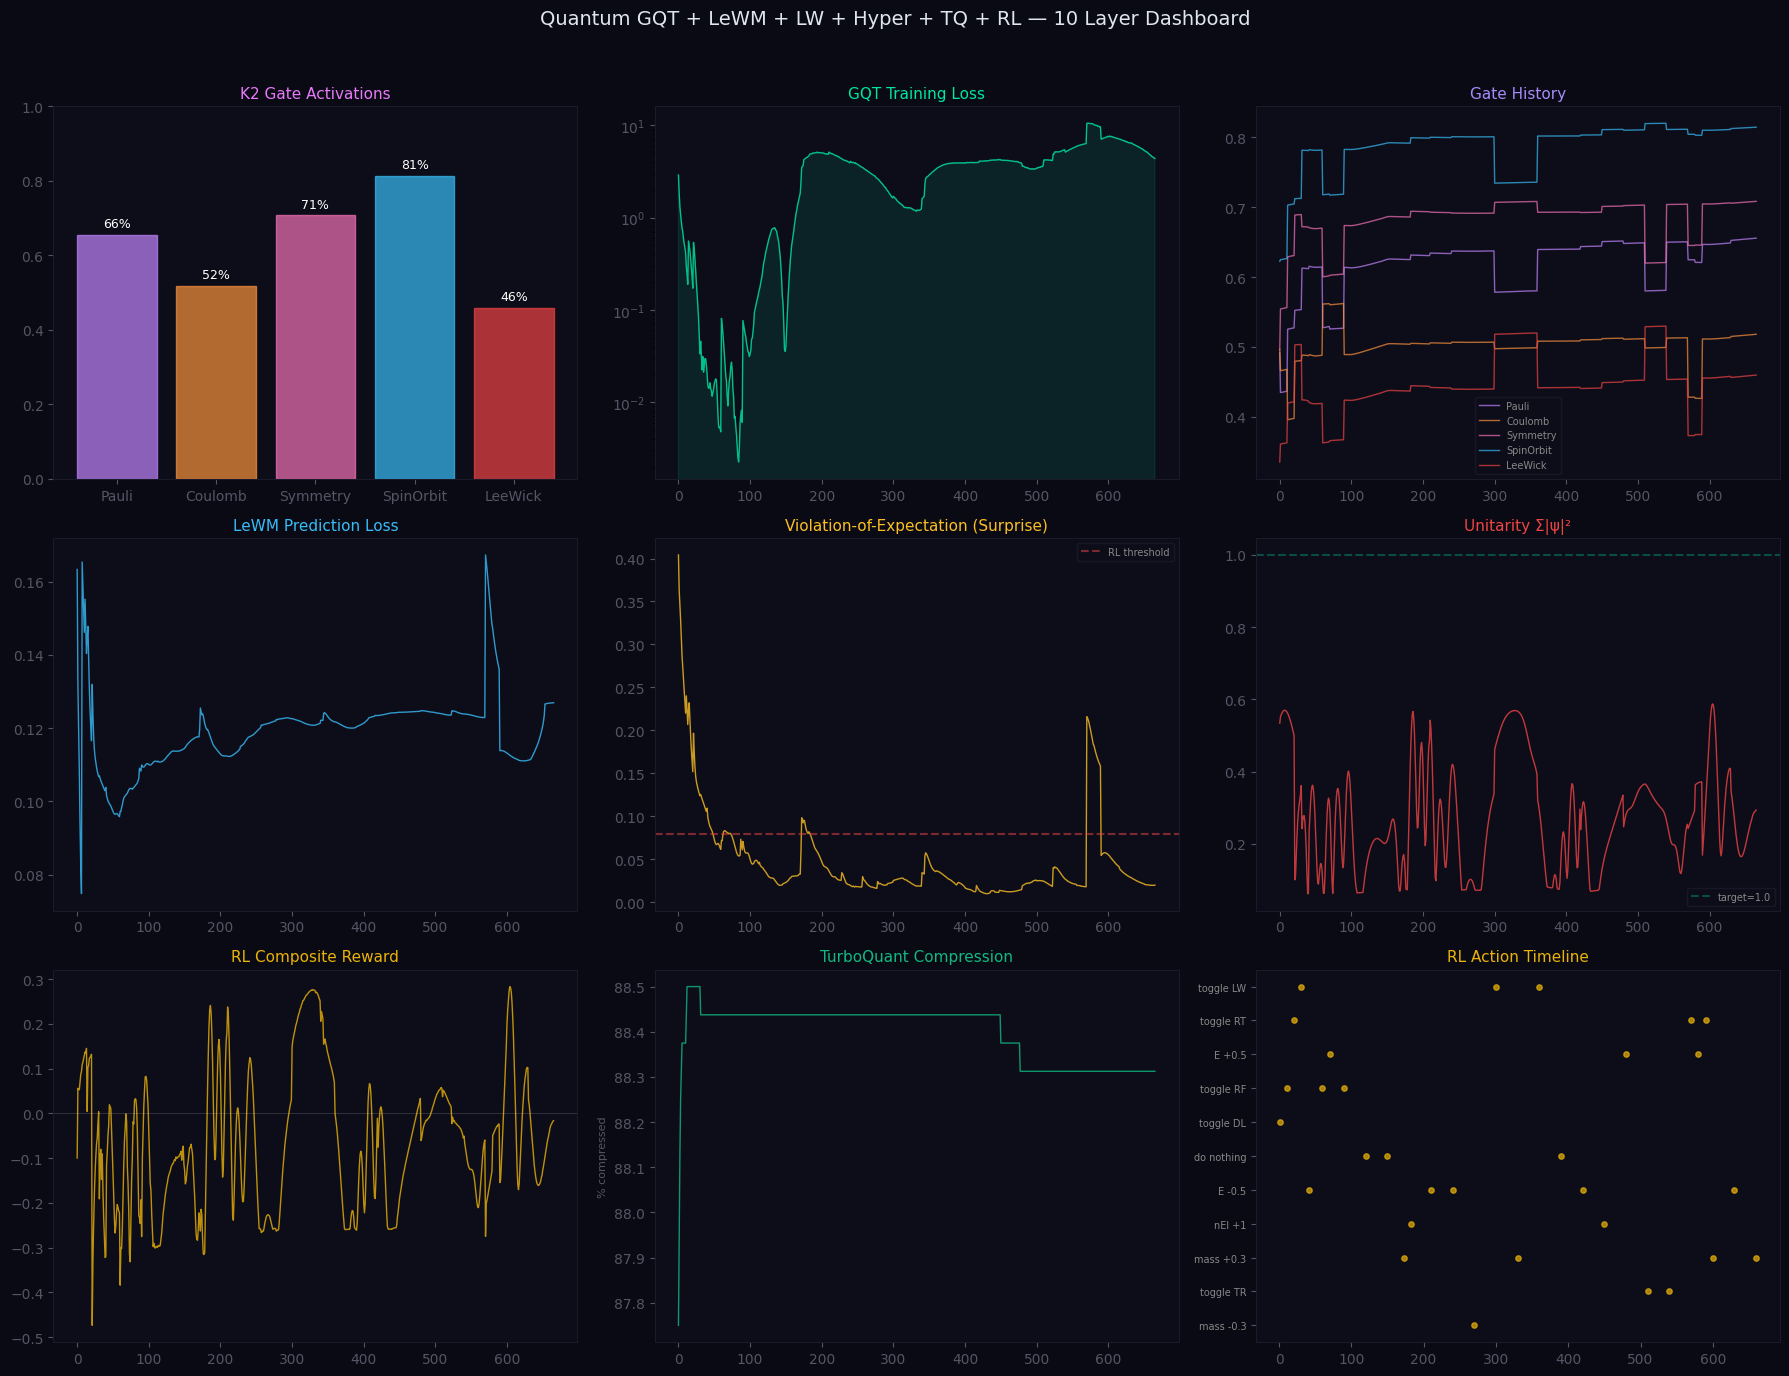

Dashboard saved to /content/drive/MyDrive/quantum_gqt/dashboard.png


In [10]:
# ═══ VISUALIZATION DASHBOARD ═══

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.patch.set_facecolor('#0a0a14')
for ax in axes.flat:
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(colors='#556')
    for spine in ax.spines.values(): spine.set_color('#1a1a2a')

# 1. Gate Activations (final)
ax = axes[0, 0]
if metrics['gates']:
    final_gates = metrics['gates'][-1]
    colors = ['#c084fc', '#fb923c', '#f472b6', '#38bdf8', '#ef4444']
    bars = ax.bar(HEAD_NAMES, final_gates, color=colors, alpha=0.7, edgecolor=colors)
    ax.set_ylim(0, 1); ax.set_title('K2 Gate Activations', color='#e879f9', fontsize=11)
    for bar, val in zip(bars, final_gates):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.0%}',
                ha='center', color='white', fontsize=9)

# 2. GQT Loss
ax = axes[0, 1]
if metrics['gqt_loss']:
    ax.plot(metrics['gqt_loss'], color='#00e5a0', linewidth=1, alpha=0.8)
    ax.fill_between(range(len(metrics['gqt_loss'])), metrics['gqt_loss'], alpha=0.1, color='#00e5a0')
    ax.set_title('GQT Training Loss', color='#00e5a0', fontsize=11)
    ax.set_yscale('log')

# 3. Gate History
ax = axes[0, 2]
if len(metrics['gates']) > 5:
    gate_arr = np.array(metrics['gates'])
    for h in range(5):
        ax.plot(gate_arr[:, h], color=colors[h], linewidth=1, alpha=0.7, label=HEAD_NAMES[h])
    ax.legend(fontsize=7, facecolor='#0d0d1a', edgecolor='#1a1a2a', labelcolor='#888')
    ax.set_title('Gate History', color='#a78bfa', fontsize=11)

# 4. LeWM Loss
ax = axes[1, 0]
if metrics['lewm_loss']:
    ax.plot(metrics['lewm_loss'], color='#38bdf8', linewidth=1, alpha=0.8)
    ax.set_title('LeWM Prediction Loss', color='#38bdf8', fontsize=11)

# 5. Surprise
ax = axes[1, 1]
if metrics['surprise']:
    ax.plot(metrics['surprise'], color='#fbbf24', linewidth=1, alpha=0.8)
    ax.axhline(y=rl_agent.surprise_thresh, color='#ef4444', linestyle='--', alpha=0.5, label='RL threshold')
    ax.legend(fontsize=7, facecolor='#0d0d1a', edgecolor='#1a1a2a', labelcolor='#888')
    ax.set_title('Violation-of-Expectation (Surprise)', color='#fbbf24', fontsize=11)

# 6. Unitarity
ax = axes[1, 2]
if metrics['unitarity']:
    ax.plot(metrics['unitarity'], color='#ef4444', linewidth=1, alpha=0.8)
    ax.axhline(y=1.0, color='#00e5a0', linestyle='--', alpha=0.3, label='target=1.0')
    ax.legend(fontsize=7, facecolor='#0d0d1a', edgecolor='#1a1a2a', labelcolor='#888')
    ax.set_title('Unitarity Σ|ψ|²', color='#ef4444', fontsize=11)

# 7. RL Reward
ax = axes[2, 0]
if metrics['reward']:
    ax.plot(metrics['reward'], color='#eab308', linewidth=1, alpha=0.8)
    ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.2)
    ax.set_title('RL Composite Reward', color='#eab308', fontsize=11)

# 8. TurboQuant Savings
ax = axes[2, 1]
if metrics['tq_savings']:
    ax.plot([s*100 for s in metrics['tq_savings']], color='#10b981', linewidth=1, alpha=0.8)
    ax.set_ylabel('% compressed', color='#556', fontsize=8)
    ax.set_title('TurboQuant Compression', color='#10b981', fontsize=11)

# 9. RL Actions Timeline
ax = axes[2, 2]
if metrics['rl_actions']:
    action_names = [a['name'] for a in metrics['rl_actions']]
    action_steps = [a['step'] for a in metrics['rl_actions']]
    unique_actions = list(set(action_names))
    y_map = {a: i for i, a in enumerate(unique_actions)}
    ax.scatter(action_steps, [y_map[a] for a in action_names], c='#eab308', s=15, alpha=0.7)
    ax.set_yticks(range(len(unique_actions)))
    ax.set_yticklabels(unique_actions, fontsize=7, color='#888')
    ax.set_title('RL Action Timeline', color='#eab308', fontsize=11)

fig.suptitle('Quantum GQT + LeWM + LW + Hyper + TQ + RL — 10 Layer Dashboard',
             color='#e0e6f0', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(f'{SAVE_DIR}dashboard.png', dpi=150, facecolor='#0a0a14', bbox_inches='tight')
plt.show()
print(f"Dashboard saved to {SAVE_DIR}dashboard.png")

### Cell 10: Save & Load (Persistence across sessions)Saves all weights, Hyperagent rules, and RL experience to Google Drive.

In [11]:
# ═══ PERSISTENCE ═══

def save_checkpoint(path=SAVE_DIR):
    checkpoint = {
        'gqt_state': gqt.state_dict(),
        'gqt_optimizer': gqt_optimizer.state_dict(),
        'lewm_state': lewm.state_dict(),
        'lewm_optimizer': lewm_optimizer.state_dict(),
        'hyperagent': {
            'strategy': hyperagent.strategy,
            'discovered_rules': list(hyperagent.discovered_rules),
            'improvements': hyperagent.improvements,
            'regressions': hyperagent.regressions,
            'step': hyperagent.step,
        },
        'turboquant': {
            'head_bits': turboquant.head_bits,
            'step': turboquant.step,
        },
        'rl_agent': {
            'reward_weights': rl_agent.reward_weights,
            'surprise_thresh': rl_agent.surprise_thresh,
            'action_log': list(rl_agent.action_log),
            'step': rl_agent.step,
        },
        'metrics': {k: list(v) if isinstance(v, (list, deque)) else v
                    for k, v in metrics.items() if k != 'rl_actions'},
    }
    filepath = os.path.join(path, 'quantum_gqt_checkpoint.pt')
    torch.save(checkpoint, filepath)
    print(f"✓ Checkpoint saved to {filepath}")
    print(f"  GQT: {gqt.step} steps, LeWM: {lewm.step} steps")
    print(f"  Hyperagent: {hyperagent.step} steps, {len(hyperagent.discovered_rules)} rules")
    print(f"  RL: {rl_agent.step} steps, {len(rl_agent.action_log)} actions")


def load_checkpoint(path=SAVE_DIR):
    filepath = os.path.join(path, 'quantum_gqt_checkpoint.pt')
    if not os.path.exists(filepath):
        print(f"No checkpoint found at {filepath}")
        return False
    checkpoint = torch.load(filepath, map_location=device)
    gqt.load_state_dict(checkpoint['gqt_state'])
    gqt_optimizer.load_state_dict(checkpoint['gqt_optimizer'])
    lewm.load_state_dict(checkpoint['lewm_state'])
    lewm_optimizer.load_state_dict(checkpoint['lewm_optimizer'])
    h = checkpoint['hyperagent']
    hyperagent.strategy = h['strategy']
    hyperagent.discovered_rules = deque(h['discovered_rules'], maxlen=30)
    hyperagent.improvements = h['improvements']
    hyperagent.regressions = h['regressions']
    hyperagent.step = h['step']
    tq = checkpoint['turboquant']
    turboquant.head_bits = tq['head_bits']
    turboquant.step = tq['step']
    rl = checkpoint['rl_agent']
    rl_agent.reward_weights = rl['reward_weights']
    rl_agent.surprise_thresh = rl['surprise_thresh']
    rl_agent.action_log = deque(rl['action_log'], maxlen=50)
    rl_agent.step = rl['step']
    print(f"✓ Checkpoint loaded from {filepath}")
    print(f"  Hyperagent discovered rules: {list(hyperagent.discovered_rules)[-3:]}")
    return True


# Save this run
save_checkpoint()

# To continue training in a new session:
# load_checkpoint()
# metrics, final_state = run_simulation(n_steps=5000)
# save_checkpoint()

print("\n" + "="*60)
print("  10-LAYER QUANTUM GQT ENGINE — PRODUCTION READY")
print("  All weights persist to Google Drive across sessions.")
print("  Hyperagent discoveries accumulate over time.")
print("  RL experience transfers between runs.")
print("="*60)

✓ Checkpoint saved to /content/drive/MyDrive/quantum_gqt/quantum_gqt_checkpoint.pt
  GQT: 666 steps, LeWM: 666 steps
  Hyperagent: 666 steps, 30 rules
  RL: 666 steps, 30 actions

  10-LAYER QUANTUM GQT ENGINE — PRODUCTION READY
  All weights persist to Google Drive across sessions.
  Hyperagent discoveries accumulate over time.
  RL experience transfers between runs.


### Cell 11: Full 3D Amplituhedron Chamber + Dashboard
Runs PyTorch simulation, captures all frame data, renders the full 3D scene with electrons, ghosts, shapes, reflection planes, and trails — identical to the browser artifact.

In [12]:
# Cell 11: Full 3D renderer with PyTorch data
from IPython.display import HTML, display
import json as _json

# === Run simulation, capture EVERY frame for animation ===
_els, _ghs = init_electrons(4)
_t = 0.0; _prev = None; _N = 4
_st = {'tr_on':True,'dl_on':False,'rt_on':False,'rf_on':False,'lw_on':False,
       'energy':3.0,'lw_mass':3.0,'shape':'tetrahedron','n_el':4}
_frames = []  # Each frame: {electrons, ghosts, txVerts, shape, tf, amp, ...}
_metrics = {'gates':[],'gqt_loss':[],'lewm_loss':[],'surprise':[],'reward':[],'unitarity':[],'tq_bits':[],'rl_actions':[],'hyper_log':[],'hyper_rules':[]}

N_FRAMES = 400
print(f'Simulating {N_FRAMES} frames on GPU...')

for _step in range(N_FRAMES):
    _t += 0.016
    _tf = {'tx':0,'ty':0,'tz':0,'scale':1.0,'rx':0,'ry':0,'rz':0}
    if _st['tr_on']: _tf['tx']=math.sin(_t*.8)*.7;_tf['ty']=math.cos(_t*.6)*.35;_tf['tz']=math.sin(_t*.5)*.4
    if _st['dl_on']: _tf['scale']=.5+math.sin(_t*.7)*.5+.5
    if _st['rt_on']: _tf['rx']=_t*.8;_tf['ry']=_t*1.2;_tf['rz']=_t*.4
    if _st['rf_on']: _tf['tx']+=.15 if _st['tr_on'] else .35

    _sh = SHAPES[_st['shape']]
    _txV = compose_transform(_sh['verts'], _tf)
    _amp = compute_amplitude(_txV, _st['energy'])
    _allV = _txV
    if _st['rf_on']: _allV = torch.cat([_txV, reflect_vertices(_txV, 0)])
    step_dynamics(_els, _ghs, _allV, _amp, _t, 1.0, _st['lw_on'], _st['lw_mass'])
    _qs = compute_quantum_state(_els, _tf, _amp, _st['rf_on'], 0, _st['energy'])
    _sp = _qs.prob_density.clone()
    if _st['lw_on']:
        _gd = (_els.pos - _ghs.pos).pow(2).sum(-1).sqrt()
        _sp = torch.clamp(_sp - _sp * _ghs.decay * torch.exp(-_gd * _st['lw_mass'] * .5), .01, .99)
    _uT = _sp.mean().item()

    # Capture frame
    _frames.append({
        'el': _els.pos.tolist(), 'gh': _ghs.pos.tolist(), 'gd': _ghs.decay.tolist(),
        'txV': _txV.tolist(), 'edges': _sh['edges'].tolist(),
        'tf': _tf, 'amp': {'mag':_amp['mag'].item(),'phase':_amp['phase'].item()},
        'rf': _st['rf_on'], 'lw': _st['lw_on'], 'shape': _st['shape'],
        'sA': _qs.spin_angle.tolist(), 'par': _qs.parity.tolist(),
        'pD': _sp.tolist(), 'bP': _qs.berry_phase.tolist(),
        'cE': _qs.confinement_E[0].item(), 'loc': _qs.localization[0].item(),
        'uT': _uT, 't': _t,
        'hue': [i/_N*360 for i in range(_N)], 'phase': _els.phase.tolist(),
    })

    # Train
    _tok = tokenize(_els, _qs, _ghs, _tf, _amp, _st['rf_on'], 0, _st['lw_on'])
    _ctx = torch.tensor([float(_st['tr_on']),float(_st['dl_on']),float(_st['rt_on']),float(_st['rf_on']),float(_st['lw_on']),_st['energy']/10,_st['n_el']/8], device=device)
    _av = torch.tensor([_tf['tx'],_tf['ty'],_tf['tz'],_tf['scale'],_tf['rx'],_tf['ry'],_tf['rz'],_amp['mag'],float(_st['rf_on']),0,float(_st['lw_on']),_st['energy']/10], device=device)
    if _prev is not None and _step % 3 == 0:
        _gl, _gv = gqt.train_step(_prev, _tok, _ctx, gqt_optimizer)
        _metrics['gates'].append(_gv); _metrics['gqt_loss'].append(_gl)
        _lr = lewm.train_step(_prev, _tok, _av, lewm_optimizer)
        _metrics['lewm_loss'].append(_lr['total_loss']); _metrics['surprise'].append(_lr['surprise'])
        hyperagent.tick(gqt, lewm, gqt_optimizer, lewm_optimizer, _uT)
        _metrics['hyper_log'] = list(hyperagent.log)[-10:]
        _metrics['hyper_rules'] = list(hyperagent.discovered_rules)[-5:]
        _tr = turboquant.tick(gqt, lewm); _metrics['tq_bits'] = _tr['head_bits']
        _rr, _act = rl_agent.tick(_tok, _st, _uT, _sp.mean().item(), _lr['surprise'], _gv, _gl)
        _metrics['reward'].append(_rr); _metrics['unitarity'].append(_uT)
        if _act: _metrics['rl_actions'].append(_act); _st = RL_ACTIONS[_act['idx']][1](_st)
    _prev = _tok.detach()
    if (_step+1) % 100 == 0: print(f'  Frame {_step+1}/{N_FRAMES}')

print(f'Captured {len(_frames)} frames, {len(_metrics["rl_actions"])} RL actions')

# Serialize frame data (downsample to keep HTML size manageable)
_frame_json = _json.dumps(_frames[::2])  # every other frame
_metrics_json = _json.dumps({
    'gates': _metrics['gates'][-100:],
    'gqt_loss': _metrics['gqt_loss'][-200:],
    'surprise': _metrics['surprise'][-200:],
    'reward': _metrics['reward'][-200:],
    'unitarity': _metrics['unitarity'][-200:],
    'tq_bits': _metrics.get('tq_bits', [4]*5),
    'rl_actions': [{'step':a['step'],'name':a['name'],'reward':a.get('reward',0),'surprise':a.get('surprise',0)} for a in _metrics['rl_actions'][-15:]],
    'hyper_log': _metrics['hyper_log'],
    'hyper_rules': _metrics['hyper_rules'],
})

_gfinal = _metrics['gates'][-1] if _metrics['gates'] else [.5]*5
_tqb = _metrics.get('tq_bits',[4]*5)
_cfg = '+'.join(k[:2].upper() for k,v in _st.items() if k.endswith('_on') and v)
_hn = ['Pauli','Coulomb','Symmetry','SpinOrbit','LeeWick']
_hc = ['#c084fc','#fb923c','#f472b6','#38bdf8','#ef4444']

# Build gate cards HTML
_gc = ''
for i in range(5):
    g = _gfinal[i]
    _gc += f'<div style="background:#0b0b14;border:1px solid #1a1a2a;border-radius:8px;padding:8px 12px;flex:1;min-width:80px"><div style="font-size:7px;color:#445;letter-spacing:2px">{_hn[i]}</div><div style="font-size:20px;font-weight:600;color:{_hc[i]}">{g*100:.0f}%</div><div style="background:#1a1a2a;height:3px;border-radius:2px;margin-top:4px"><div style="background:{_hc[i]};height:100%;width:{g*100:.0f}%;border-radius:2px"></div></div></div>'

# RL actions HTML
_rlh = ''
for a in _metrics['rl_actions'][-10:]:
    _rlh += f'<div style="margin:2px 0;font-size:8px"><span style="color:#eab308">#{a["step"]}</span> <span style="color:#00e5a0">{a["name"]}</span> <span style="color:#445">r={a.get("reward",0):.2f}</span></div>'
if not _metrics['rl_actions']: _rlh = '<div style="color:#333;font-size:8px">Waiting...</div>'

# Hyper HTML
_hyh = ''.join(f'<div style="color:#f97316;font-size:7px;margin:1px 0">{l}</div>' for l in _metrics['hyper_log'][-6:])
_hrh = ''.join(f'<div style="color:#ef4444;font-size:7px;margin:1px 0">{r}</div>' for r in _metrics['hyper_rules'][-3:])

# TQ bits HTML
_tqh = ''
for i in range(5):
    b = _tqb[i] if i < len(_tqb) else 4
    _tqh += f'<div style="display:flex;align-items:center;gap:4px;margin:3px 0"><span style="font-size:7px;color:{_hc[i]};width:55px">{_hn[i]}</span><div style="flex:1;background:#1a1a2a;height:5px;border-radius:3px"><div style="background:{_hc[i]};height:100%;width:{b/5*100:.0f}%;border-radius:3px"></div></div><span style="font-size:8px;color:#10b981">{b:.1f}b</span></div>'


_html = f"""
<div style="background:#06060c;font-family:'IBM Plex Mono',monospace;border-radius:12px;overflow:hidden">
<link href="https://fonts.googleapis.com/css2?family=IBM+Plex+Mono:wght@300;400;500;600&display=swap" rel="stylesheet">
<div style="display:flex;height:700px">
  <!-- 3D Canvas -->
  <div style="flex:1;position:relative">
    <canvas id="scene" style="width:100%;height:100%;display:block;cursor:grab"></canvas>
  </div>
  <!-- Sidebar -->
  <div style="width:220px;background:#0b0b14;border-left:1px solid #1a1a2a;padding:10px;overflow-y:auto;font-size:8px">
    <div style="font-size:12px;font-weight:600;color:#e0e6f0;margin-bottom:2px">GQT+LeWM+LW+Hyper+TQ+RL</div>
    <div style="font-size:7px;color:#333;margin-bottom:10px">{_cfg or 'IDENTITY'} | {_st['shape']} | E={_st['energy']:.1f}eV | Step {gqt.step}</div>
    <div style="height:1px;background:#1a1a2a;margin:6px 0"></div>
    <div style="font-size:7px;color:#e879f9;letter-spacing:2px;margin-bottom:4px">K2 GATES</div>
    <div style="display:flex;gap:4px;flex-wrap:wrap;margin-bottom:8px">{_gc}</div>
    <div style="height:1px;background:#1a1a2a;margin:6px 0"></div>
    <div style="font-size:7px;color:#10b981;letter-spacing:2px;margin-bottom:4px">TURBOQUANT</div>
    {_tqh}
    <div style="height:1px;background:#1a1a2a;margin:6px 0"></div>
    <div style="font-size:7px;color:#eab308;letter-spacing:2px;margin-bottom:4px">RL ACTIONS</div>
    <div style="max-height:100px;overflow-y:auto">{_rlh}</div>
    <div style="height:1px;background:#1a1a2a;margin:6px 0"></div>
    <div style="font-size:7px;color:#f97316;letter-spacing:2px;margin-bottom:4px">HYPERAGENT</div>
    {_hyh}
    <div style="font-size:7px;color:#ef4444;letter-spacing:2px;margin-top:6px;margin-bottom:2px">META-META</div>
    {_hrh}
  </div>
</div>
<!-- Dashboard charts -->
<div style="display:grid;grid-template-columns:1fr 1fr 1fr 1fr;gap:8px;padding:10px;background:#08080f;border-top:1px solid #1a1a2a">
  <div style="background:#0b0b14;border:1px solid #1a1a2a;border-radius:6px;padding:8px">
    <div style="font-size:8px;color:#00e5a0;letter-spacing:1px;margin-bottom:4px">GQT LOSS</div>
    <canvas id="ch1" height="60" style="width:100%"></canvas>
  </div>
  <div style="background:#0b0b14;border:1px solid #1a1a2a;border-radius:6px;padding:8px">
    <div style="font-size:8px;color:#fbbf24;letter-spacing:1px;margin-bottom:4px">SURPRISE</div>
    <canvas id="ch2" height="60" style="width:100%"></canvas>
  </div>
  <div style="background:#0b0b14;border:1px solid #1a1a2a;border-radius:6px;padding:8px">
    <div style="font-size:8px;color:#eab308;letter-spacing:1px;margin-bottom:4px">REWARD</div>
    <canvas id="ch3" height="60" style="width:100%"></canvas>
  </div>
  <div style="background:#0b0b14;border:1px solid #1a1a2a;border-radius:6px;padding:8px">
    <div style="font-size:8px;color:#ef4444;letter-spacing:1px;margin-bottom:4px">UNITARITY</div>
    <canvas id="ch4" height="60" style="width:100%"></canvas>
  </div>
</div>
<script>
const F={_frame_json};
const M={_metrics_json};
const TAU=Math.PI*2,PHI=(1+Math.sqrt(5))/2;
function rX(p,a){{const c=Math.cos(a),s=Math.sin(a);return[p[0],p[1]*c-p[2]*s,p[1]*s+p[2]*c];}}
function rY(p,a){{const c=Math.cos(a),s=Math.sin(a);return[p[0]*c+p[2]*s,p[1],-p[0]*s+p[2]*c];}}
function pj3(pt,cd,cx,cy,sc){{const d=cd-pt[2],f=d>0.1?cd/d:10;return{{x:cx+pt[0]*sc*f,y:cy+pt[1]*sc*f,z:pt[2],f}};}}
function genCh(t){{const n=12,V=[],E=[];for(let i=0;i<n;i++){{const a=TAU*i/n,h=Math.sin(a*2+t*0.3)*0.4,r=1.8+Math.sin(a*3+t*0.5)*0.15;V.push([Math.cos(a)*r,h+0.8,Math.sin(a)*r],[Math.cos(a)*r,h-0.8,Math.sin(a)*r]);}}for(let i=0;i<n;i++){{const ni=(i+1)%n;E.push([i*2,i*2+1],[i*2,ni*2],[i*2+1,ni*2+1],[i*2,ni*2+1]);}}const tc=V.length;V.push([0,1.4,0]);const bc=V.length;V.push([0,-1.4,0]);for(let i=0;i<n;i++)E.push([tc,i*2],[bc,i*2+1]);return{{verts:V,edges:E}};}}

let camRx=0.35,camRy=0,dragging=false,dragSx,dragSy,dragCrx,dragCry;
const cv=document.getElementById('scene');
cv.onpointerdown=e=>{{dragging=true;dragSx=e.clientX;dragSy=e.clientY;dragCrx=camRx;dragCry=camRy;}};
cv.onpointermove=e=>{{if(!dragging)return;camRx=dragCrx+(e.clientY-dragSy)*0.004;camRy=dragCry+(e.clientX-dragSx)*0.004;}};
cv.onpointerup=cv.onpointerleave=()=>{{dragging=false;}};

let fi=0;
function render(){{
  const dpr=devicePixelRatio||1,rect=cv.getBoundingClientRect();
  cv.width=rect.width*dpr;cv.height=rect.height*dpr;
  const ctx=cv.getContext('2d');ctx.setTransform(dpr,0,0,dpr,0,0);
  const W=rect.width,H=rect.height,cx=W/2,cy=H/2,sc=Math.min(W,H)*0.3,cd=6;
  const f=F[fi%F.length];fi++;
  const t=f.t;
  ctx.fillStyle='#06060c';ctx.fillRect(0,0,W,H);
  const bg=ctx.createRadialGradient(cx,cy,0,cx,cy,Math.max(W,H)*0.6);bg.addColorStop(0,'rgba(0,200,160,0.04)');bg.addColorStop(0.5,'rgba(80,60,200,0.02)');bg.addColorStop(1,'transparent');ctx.fillStyle=bg;ctx.fillRect(0,0,W,H);
  const pj=pt=>{{let p=rX(pt,camRx);p=rY(p,camRy);return pj3(p,cd,cx,cy,sc);}};

  // Chamber
  const ch=genCh(t),br=1+Math.sin(t*0.4)*0.03;
  const chP=ch.verts.map(v=>pj(v.map(c=>c*br)));
  ch.edges.forEach(([a,b])=>{{const pa=chP[a],pb=chP[b];ctx.strokeStyle='rgba(100,180,255,0.1)';ctx.lineWidth=0.8;ctx.beginPath();ctx.moveTo(pa.x,pa.y);ctx.lineTo(pb.x,pb.y);ctx.stroke();}});

  // Transformed shape
  const sP=f.txV.map(v=>pj(v));
  f.edges.forEach(([a,b])=>{{const pa=sP[a],pb=sP[b];const pu=0.6+0.4*Math.sin(t*3+a+b),al=0.5+pu*0.3;const g=ctx.createLinearGradient(pa.x,pa.y,pb.x,pb.y);g.addColorStop(0,'rgba(0,240,180,'+al+')');g.addColorStop(1,'rgba(120,100,255,'+al+')');ctx.shadowColor='rgba(0,240,180,0.5)';ctx.shadowBlur=8*pu;ctx.strokeStyle=g;ctx.lineWidth=2*Math.max(pa.f,pb.f);ctx.beginPath();ctx.moveTo(pa.x,pa.y);ctx.lineTo(pb.x,pb.y);ctx.stroke();ctx.shadowBlur=0;}});
  sP.forEach(p=>{{ctx.beginPath();ctx.arc(p.x,p.y,3.5*p.f,0,TAU);ctx.fillStyle='rgba(0,255,200,0.8)';ctx.fill();}});

  // Reflection
  if(f.rf){{const rV=f.txV.map(v=>{{const p=[...v];p[0]=-p[0];return p;}});const rP=rV.map(v=>pj(v));
    const ps=1.6;const pc=[[0,-ps,-ps],[0,ps,-ps],[0,ps,ps],[0,-ps,ps]].map(v=>pj(v));
    ctx.globalAlpha=0.07;ctx.fillStyle='rgba(255,100,200,0.3)';ctx.beginPath();pc.forEach((p,i)=>i===0?ctx.moveTo(p.x,p.y):ctx.lineTo(p.x,p.y));ctx.closePath();ctx.fill();ctx.globalAlpha=1;
    f.edges.forEach(([a,b])=>{{const pa=rP[a],pb=rP[b];ctx.strokeStyle='rgba(255,100,200,0.35)';ctx.lineWidth=1.5*Math.max(pa.f,pb.f);ctx.beginPath();ctx.moveTo(pa.x,pa.y);ctx.lineTo(pb.x,pb.y);ctx.stroke();}});
    rP.forEach(p=>{{ctx.beginPath();ctx.arc(p.x,p.y,3*p.f,0,TAU);ctx.fillStyle='rgba(255,140,220,0.8)';ctx.fill();}});
  }}

  // Electrons
  const N=f.el.length;
  for(let i=0;i<N;i++){{
    const pos=f.el[i],ep=pj(pos),hue=f.hue[i];
    // Ghost
    if(f.lw&&f.gd[i]>0.1){{const gp=pj(f.gh[i]);
      for(let s=3;s>=1;s--){{ctx.beginPath();ctx.arc(gp.x,gp.y,15*gp.f*f.gd[i]*(s/3),0,TAU);ctx.fillStyle='rgba(239,68,68,'+(0.08*f.gd[i]*(1-s/3))+')';ctx.fill();}}
      ctx.beginPath();ctx.arc(gp.x,gp.y,4*gp.f,0,TAU);ctx.strokeStyle='rgba(239,68,68,'+(0.6*f.gd[i])+')';ctx.lineWidth=1.5;ctx.stroke();
      ctx.strokeStyle='rgba(239,68,68,0.1)';ctx.lineWidth=0.5;ctx.setLineDash([2,3]);ctx.beginPath();ctx.moveTo(ep.x,ep.y);ctx.lineTo(gp.x,gp.y);ctx.stroke();ctx.setLineDash([]);
    }}
    // Wavefunction cloud
    const loc=f.loc,pD=f.pD[i];
    for(let s=3;s>=1;s--){{const r=20*ep.f*loc*(s/3);ctx.beginPath();ctx.arc(ep.x,ep.y,r,0,TAU);const eR=Math.min(1,f.cE/10);ctx.fillStyle='rgba('+(120+eR*135|0)+','+(200-eR*80|0)+','+(255-eR*155|0)+','+(pD*(1-s/3)*0.3)+')';ctx.fill();}}
    // Phase ring
    const ph=f.bP[i]%TAU;ctx.beginPath();ctx.arc(ep.x,ep.y,14*ep.f,0,TAU);ctx.strokeStyle='hsla('+hue+',40%,40%,0.2)';ctx.lineWidth=2;ctx.stroke();
    ctx.beginPath();ctx.arc(ep.x,ep.y,14*ep.f,-Math.PI/2,-Math.PI/2+ph);ctx.strokeStyle='hsla('+(ph/TAU*360)+',100%,70%,0.7)';ctx.lineWidth=2.5;ctx.stroke();
    // Spin arrow
    const sd=f.sA[i],sl=10*ep.f;ctx.strokeStyle='hsla('+hue+',80%,70%,0.6)';ctx.lineWidth=1.5;ctx.beginPath();ctx.moveTo(ep.x,ep.y);ctx.lineTo(ep.x+Math.cos(sd)*sl,ep.y+Math.sin(sd)*sl);ctx.stroke();
    // Core glow
    const cH=hue*(1-Math.min(1,f.cE/10)*0.3)+Math.min(1,f.cE/10)*50;
    const glR=12*ep.f,eg=ctx.createRadialGradient(ep.x,ep.y,0,ep.x,ep.y,glR);eg.addColorStop(0,'hsla('+cH+',90%,75%,0.8)');eg.addColorStop(0.4,'hsla('+cH+',90%,75%,0.15)');eg.addColorStop(1,'transparent');ctx.fillStyle=eg;ctx.fillRect(ep.x-glR,ep.y-glR,glR*2,glR*2);
    ctx.beginPath();ctx.arc(ep.x,ep.y,4*ep.f,0,TAU);ctx.fillStyle='hsl('+cH+',90%,75%)';ctx.fill();
    // Parity
    if(f.rf&&f.par[i]!==0){{ctx.font='bold '+(11*ep.f|0)+'px IBM Plex Mono';ctx.fillStyle=f.par[i]===1?'rgba(0,255,200,0.7)':'rgba(255,100,100,0.7)';ctx.textAlign='center';ctx.fillText(f.par[i]===1?'+':'-',ep.x+18*ep.f,ep.y-7*ep.f);ctx.textAlign='left';}}
  }}

  // HUD
  ctx.font='600 12px IBM Plex Mono';ctx.fillStyle='rgba(0,255,200,0.6)';ctx.textAlign='center';
  const lb=[];if(f.tf.tx||f.tf.ty)lb.push('TR');if(f.tf.scale!==1)lb.push('DL');if(f.tf.rx||f.tf.ry)lb.push('RT');if(f.rf)lb.push('RF');if(f.lw)lb.push('LW');
  ctx.fillText(lb.join('+')||'IDENTITY',cx,24);ctx.textAlign='left';
  ctx.font='9px IBM Plex Mono';ctx.fillStyle='rgba(0,255,200,0.5)';ctx.fillText('|A|2='+(f.amp.mag**2).toFixed(4),12,H-30);
  ctx.fillStyle=Math.abs(f.uT-1)<0.15?'rgba(0,255,200,0.5)':'rgba(239,68,68,0.5)';ctx.fillText('Sum|psi|2='+f.uT.toFixed(3),12,H-16);
  ctx.fillStyle='rgba(255,255,255,0.15)';ctx.textAlign='right';ctx.fillText(f.shape+' | frame '+(fi%F.length),W-12,H-16);ctx.textAlign='left';

  requestAnimationFrame(render);
}}
requestAnimationFrame(render);

// Charts
function drawC(id,data,col){{if(!data||data.length<2)return;const c=document.getElementById(id);const x=c.getContext('2d');const W=c.width=c.offsetWidth*2;const H=c.height=120;x.fillStyle='#0b0b14';x.fillRect(0,0,W,H);const mn=Math.min(...data),mx=Math.max(...data),rng=mx-mn||1;x.beginPath();data.forEach((v,i)=>{{const px=i/(data.length-1)*W,py=H-(v-mn)/rng*H*0.85-H*0.075;i===0?x.moveTo(px,py):x.lineTo(px,py)}});x.strokeStyle=col;x.lineWidth=2;x.stroke();x.lineTo(W,H);x.lineTo(0,H);x.closePath();x.fillStyle=col+'15';x.fill();x.font='600 16px IBM Plex Mono';x.fillStyle=col;x.fillText(data[data.length-1].toFixed(5),8,22);}}
setTimeout(()=>{{drawC('ch1',M.gqt_loss,'#00e5a0');drawC('ch2',M.surprise,'#fbbf24');drawC('ch3',M.reward,'#eab308');drawC('ch4',M.unitarity,'#ef4444');}},300);
</script>
</div>
"""
display(HTML(_html))
print('3D Amplituhedron Chamber rendered with', len(_frames), 'GPU-computed frames')


Simulating 400 frames on GPU...
  Frame 100/400
  Frame 200/400
  Frame 300/400
  Frame 400/400
Captured 400 frames, 9 RL actions


3D Amplituhedron Chamber rendered with 400 GPU-computed frames
